In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project-wide publication styling helpers.
sys.path.insert(0, str(Path("../../meta/tools").resolve()))
import plot_utils as pu  # noqa: E402

pu.set_publication_style()
PALETTE = pu.apply_color_palette("default", n_colors=10)

SAVEPATH = "./figure"
os.makedirs(SAVEPATH, exist_ok=True)

In [2]:
CSV_PATH = Path("../../.local/summary-1.7B.csv")

df = pd.read_csv(CSV_PATH)

# IMPORTANT (see contrib/benchmark_overhead/runs/NOTES.md):
#   `head_p2p_to_worker_first_byte` is measured from the head's p2p send to the
#   worker's first response byte — it INCLUDES `worker_local_proxy` and
#   `worker_sglang_ttft`. So those stages are NOT additive.
#
# The honest OpenTela overhead is `otela.ttft - direct.ttft`. We decompose it
# from the per-stage telemetry as:
#
#   head_routing      = head_recv + head_dnt + head_peer_select
#   head_forward      = head_p2p_to_worker_first_byte
#                       - worker_sglang_ttft - worker_local_proxy
#                       # libp2p forward leg (head→worker)
#   local_forward     = worker_local_proxy
#                       # worker handler → local reverse-proxy
#   others            = (otela.ttft - direct.ttft) - (head_routing
#                       + head_forward + local_forward)
#                       # libp2p return leg + head↔client network diff

direct = df[df["path"] == "direct"].set_index("rps").sort_index()
otela  = df[df["path"] == "otela"].set_index("rps").sort_index()
common_rps = sorted(set(direct.index) & set(otela.index))

def s50(rps: int, col: str) -> float:
    return float(otela.loc[rps, f"{col}_p50_ms"])

def sstd(rps: int, col: str) -> float:
    return float(otela.loc[rps, f"{col}_std_ms"])

def quad(*xs: float) -> float:
    return float(np.sqrt(sum(x * x for x in xs)))

def residual_std(outer_std: float, *inner_stds: float) -> float:
    """Std of (outer − sum(inner)) when `outer` is a measured superset of the
    inner stages. var(outer) = sum(var(inner)) + var(residual)."""
    return float(np.sqrt(max(0.0, outer_std * outer_std - sum(s * s for s in inner_stds))))

rows = []
for r in common_rps:
    head_routing      = s50(r, "head_recv") + s50(r, "head_dnt") + s50(r, "head_peer_select")
    head_routing_std  = quad(sstd(r, "head_recv"), sstd(r, "head_dnt"), sstd(r, "head_peer_select"))

    head_forward      = s50(r, "head_p2p_to_worker_first_byte") \
                        - s50(r, "worker_sglang_ttft") - s50(r, "worker_local_proxy")
    head_forward_std  = residual_std(
        sstd(r, "head_p2p_to_worker_first_byte"),
        sstd(r, "worker_sglang_ttft"),
        sstd(r, "worker_local_proxy"),
    )

    local_forward     = s50(r, "worker_local_proxy")
    local_forward_std = sstd(r, "worker_local_proxy")

    llm_inference     = s50(r, "worker_sglang_ttft")
    llm_inference_std = sstd(r, "worker_sglang_ttft")

    total_overhead    = float(otela.loc[r, "ttft_p50_ms"]) - float(direct.loc[r, "ttft_p50_ms"])
    others            = total_overhead - (head_routing + head_forward + local_forward)
    others_std        = head_forward_std  # return leg has the same character as forward leg
    total_overhead_std = quad(head_routing_std, head_forward_std, local_forward_std, others_std)

    rows.append({
        "rps": r,
        "llm_inference_ms":    llm_inference,
        "llm_inference_std":   llm_inference_std,
        "head_routing_ms":     head_routing,
        "head_routing_std":    head_routing_std,
        "head_forward_ms":     head_forward,
        "head_forward_std":    head_forward_std,
        "local_forward_ms":    local_forward,
        "local_forward_std":   local_forward_std,
        "others_ms":           others,
        "others_std":          others_std,
        "total_overhead_ms":   total_overhead,
        "total_overhead_std":  total_overhead_std,
    })

bd = pd.DataFrame(rows).set_index("rps")
bd

,llm_inference_ms,llm_inference_std,head_routing_ms,head_routing_std,head_forward_ms,head_forward_std,local_forward_ms,local_forward_std,others_ms,others_std,total_overhead_ms,total_overhead_std
rps,,,,,,,,,,,,
1,12.570,0.690,0.074,0.014526,1.024,0.269926,0.059,0.011,1.220,0.269926,2.377,0.382168
4,12.313,0.593,0.069,0.011045,0.897,0.256020,0.053,0.011,0.986,0.256020,2.005,0.362402
16,12.787,3.785,0.066,0.011790,0.946,0.598262,0.057,0.009,1.269,0.598262,2.338,0.846201


Saved figure: ./figure/overhead_breakdown.pdf


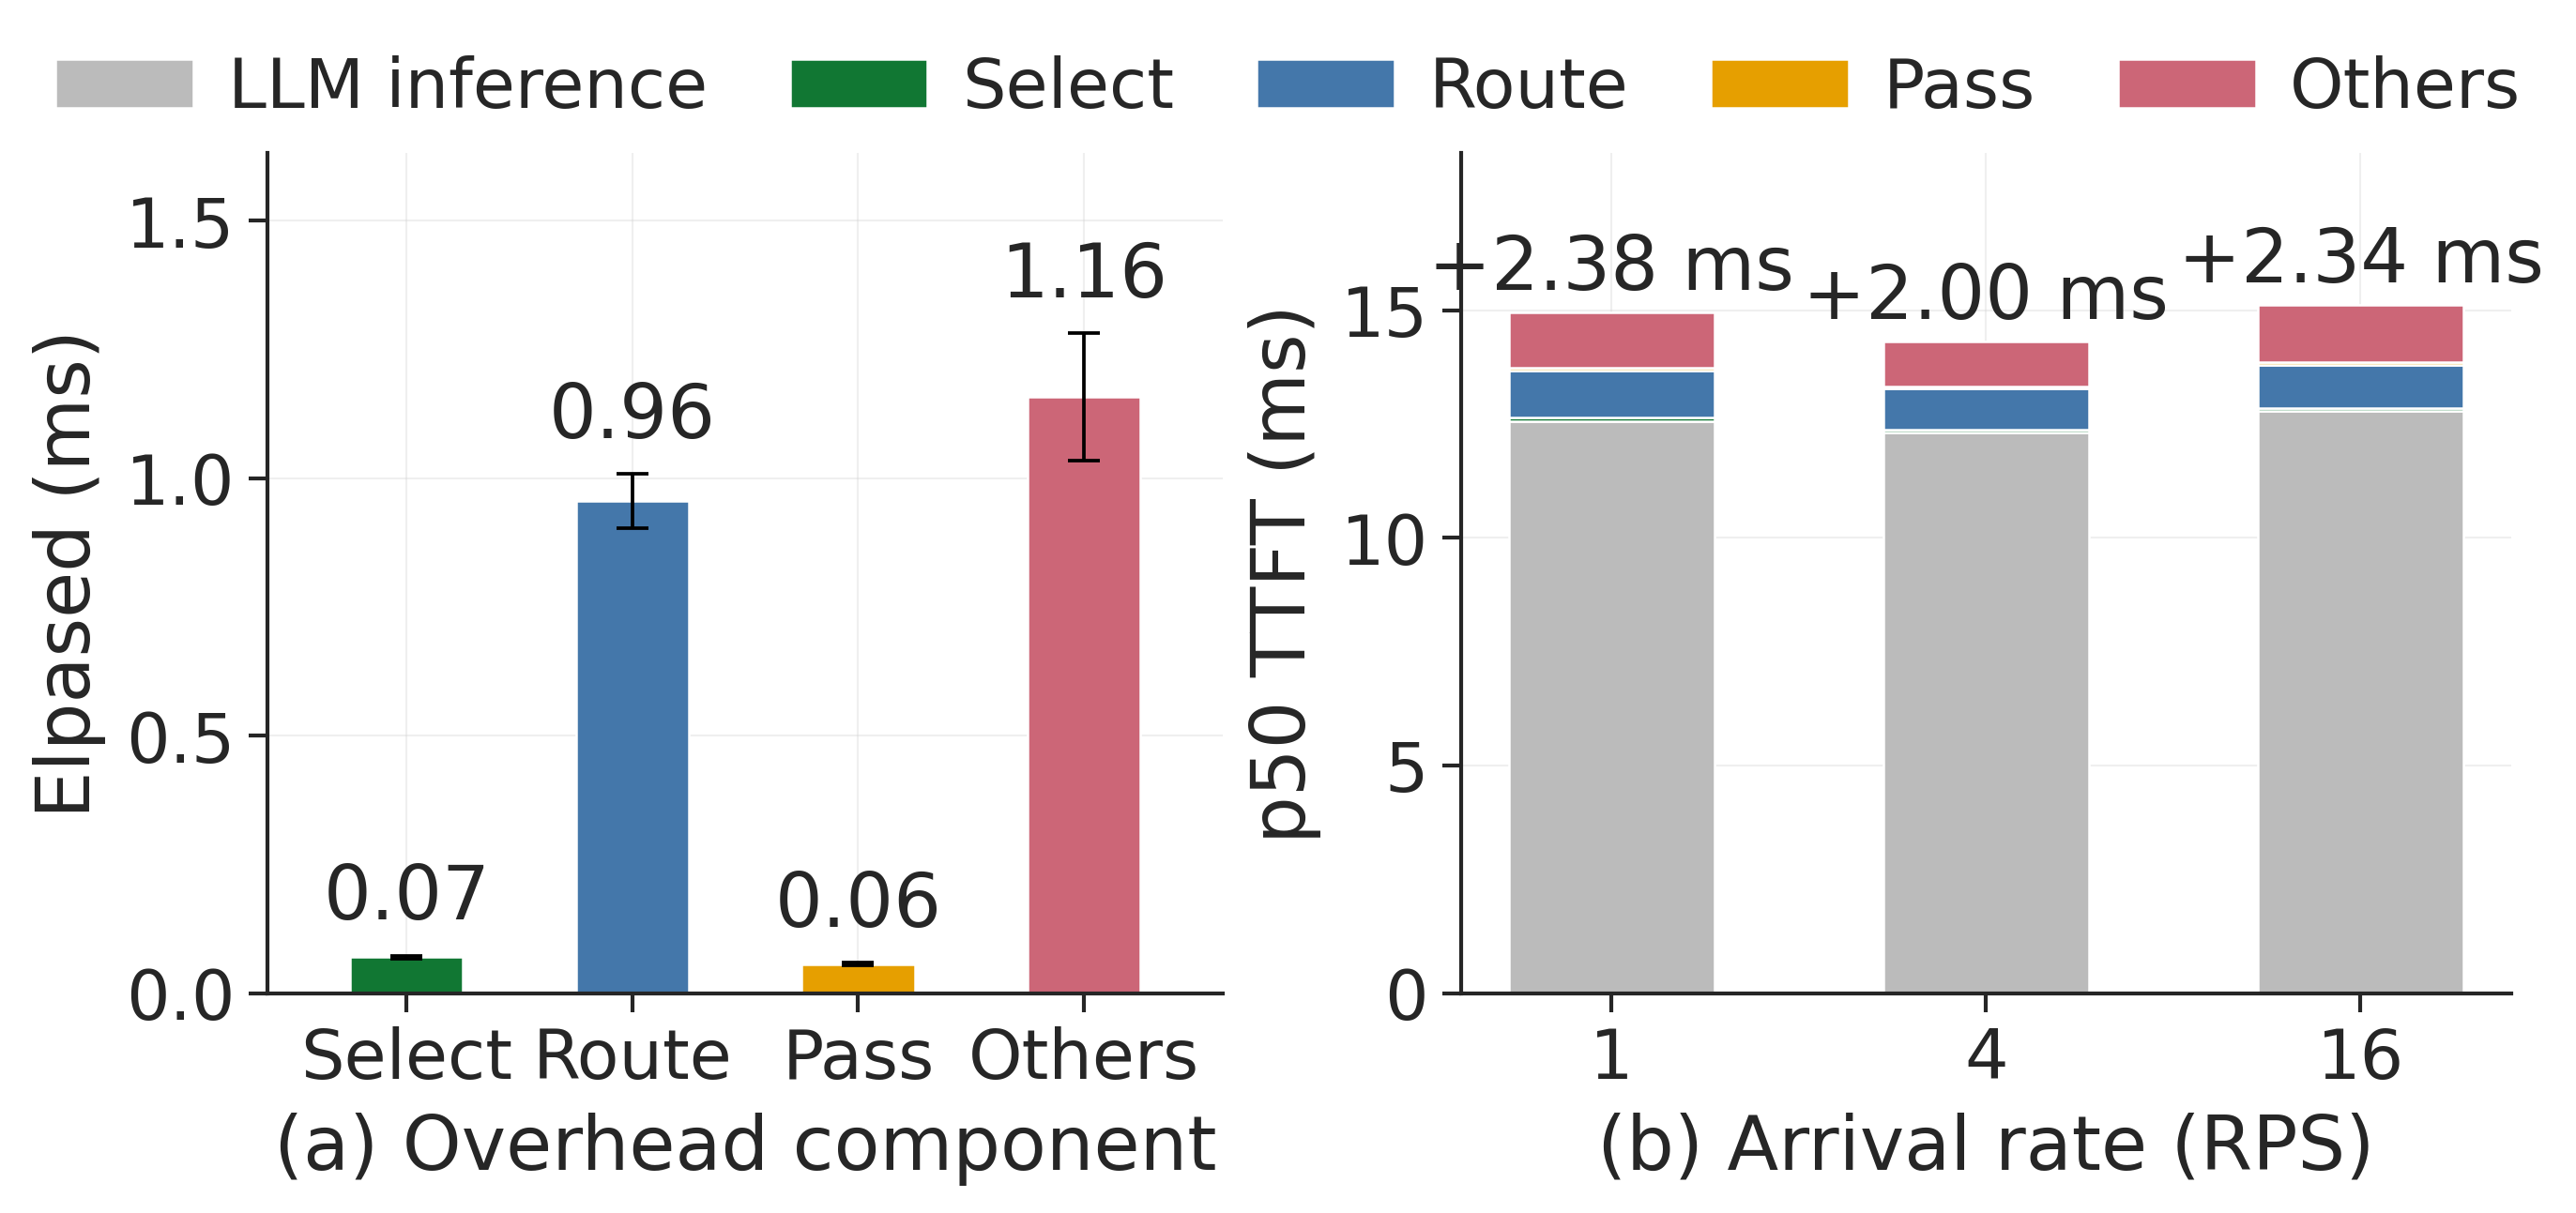

In [8]:
COMPONENTS = [
    ("head_routing",  "Select"),
    ("head_forward",  "Route"),
    ("local_forward", "Pass"),
    ("others",        "Others"),
]

# Colors drawn from plot_utils "default" palette (Tol/Okabe-style).
COMP_COLORS = {
    "head_routing":  PALETTE[3],   # green
    "head_forward":  PALETTE[9],   # steel blue
    "local_forward": PALETTE[0],   # orange
    "others":        PALETTE[6],   # rose
}
LLM_COLOR = PALETTE[2]  # neutral grey for LLM inference

rps_list = list(bd.index)

fig, (axL, axR) = pu.create_default_side_by_side_figure(
    figsize=(9, 3.75),
    gridspec_kw={"width_ratios": [1.0, 1.1]},
)

# ============================================================================
# (a) Per-component overhead — mean ± std across RPS levels
# ============================================================================
# Spread bars on a 1.3× pitch so two-line x-tick labels don't overlap.
x_pitch = 1.3
x = np.arange(len(COMPONENTS)) * x_pitch
heights = [bd[f"{key}_ms"].mean() for key, _ in COMPONENTS]
errs    = [bd[f"{key}_ms"].std(ddof=0) for key, _ in COMPONENTS]
colors  = [COMP_COLORS[key] for key, _ in COMPONENTS]

bars = axL.bar(
    x, heights, width=0.65,
    color=colors, edgecolor="white", linewidth=0.6,
    yerr=errs, capsize=4,
    error_kw=dict(ecolor="black", elinewidth=0.9, capthick=0.9),
)
for b, m, e in zip(bars, heights, errs):
    axL.text(b.get_x() + b.get_width() / 2, m + e + 0.04,
             f"{m:.2f}", ha="center", va="bottom")

axL.set_xticks(x)
axL.set_xticklabels([lbl for _, lbl in COMPONENTS])
axL.set_xlim(x[0] - 0.8, x[-1] + 0.8)
pu.style_axes(
    axL,
    xlabel="(a) Overhead component",
    ylabel="Elpased (ms)",
    ylim=(0, max(heights) + max(errs) + 0.35),
    grid=True,
)

rps_x = np.arange(len(rps_list))
bar_w = 0.55

llm_h = np.array([bd.loc[r, "llm_inference_ms"] for r in rps_list])
axR.bar(rps_x, llm_h, width=bar_w, color=LLM_COLOR,
        edgecolor="white", linewidth=0.6, label="LLM inference")

bottoms = llm_h.copy()
for key, two_line_label in COMPONENTS:
    h = np.array([bd.loc[r, f"{key}_ms"] for r in rps_list])
    axR.bar(rps_x, h, bottom=bottoms, width=bar_w,
            color=COMP_COLORS[key], edgecolor="white", linewidth=0.6,
            label=two_line_label.replace("\n", " "))
    bottoms += h

for i, r in enumerate(rps_list):
    overhead = bd.loc[r, "total_overhead_ms"]
    axR.text(rps_x[i], bottoms[i] + 0.15,
             f"+{overhead:.2f} ms",
             ha="center", va="bottom")

axR.set_xticks(rps_x)
axR.set_xticklabels([str(r) for r in rps_list])
pu.style_axes(
    axR,
    xlabel="(b) Arrival rate (RPS)",
    ylabel="p50 TTFT (ms)",
    ylim=(0, bottoms.max() * 1.22),
    grid=True,
)

# Shared legend above the figure.
handles, labels = axR.get_legend_handles_labels()
fig.legend(
    handles=handles, labels=labels,
    ncols=len(handles),
    bbox_to_anchor=(0.5, 1.05), loc="center",
    columnspacing=1.2, handletextpad=0.5, frameon=False,
)

pu.save_figure(fig, f"{SAVEPATH}/overhead_breakdown", formats=["pdf"])
plt.show()